# 01 — Discharge Event Detection

Loads the raw discharge timeseries from the Rakafot gauge, detects flow events,
merges events that are close in time, and saves a clean event table.

**Output:** `flow_events_processed.csv`

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import config as cfg
from utils.discharge import load_discharge, detect_raw_events, build_event_table, merge_close_events
from utils.plots import nice_hist, plot_events_over_time

## 1  Load and detect raw events

In [2]:
discharge = load_discharge(cfg.DISCHARGE_RAW_CSV)
print(f"Loaded {len(discharge):,} rows  |  "
      f"{discharge['timestamp'].min().date()} → {discharge['timestamp'].max().date()}")
discharge.head()

Loaded 262,818 rows  |  2023-10-04 → 2026-04-29


,timestamp,discharge_cms
0,2023-10-04 11:05:08,0.0
1,2023-10-04 11:08:08,0.0
2,2023-10-04 11:11:08,0.0
3,2023-10-04 11:15:00,0.0
4,2023-10-04 11:20:00,0.0


In [3]:
discharge = detect_raw_events(discharge, threshold=cfg.FLOW_THRESHOLD_CMS)
n_raw = discharge['raw_event_id'].max()
print(f"Detected {n_raw} raw events (threshold = {cfg.FLOW_THRESHOLD_CMS} m³/s)")

Detected 599 raw events (threshold = 0.01 m³/s)


## 2  Build event table and merge close events

In [4]:
raw_events   = build_event_table(discharge)
flow_events  = merge_close_events(raw_events, max_gap_hours=cfg.MERGE_GAP_HOURS)

print(f"Raw events   : {len(raw_events)}")
print(f"After merge  : {len(flow_events)}  (gap ≤ {cfg.MERGE_GAP_HOURS} h)")
flow_events.head()

Raw events   : 302
After merge  : 61  (gap ≤ 48 h)


,flow_start,flow_end,flow_peak_datetime,flow_peak_m3_s,flow_total_volume_m3
0,2023-11-01 12:20:00,2023-11-03 11:00:00,2023-11-01 13:50:00,0.617218,1773.301946
1,2023-11-14 16:30:00,2023-11-14 17:05:00,2023-11-14 16:40:00,0.063550,39.911987
2,2023-11-19 14:20:00,2023-11-21 16:15:00,2023-11-20 02:55:00,0.394052,7530.163635
3,2023-11-27 04:05:00,2023-11-27 18:10:00,2023-11-27 13:30:00,0.218358,2319.086856
4,2023-12-05 16:20:00,2023-12-06 12:40:00,2023-12-05 17:50:00,0.166977,545.809527


## 3  Save

In [5]:
# Split datetimes back to separate date/time columns for compatibility
out = flow_events.copy()
for col in ['flow_start', 'flow_end', 'flow_peak_datetime']:
    label = col.replace('flow_', '').replace('_datetime', '')
    out[f'flow_{label}_date'] = out[col].dt.date
    out[f'flow_{label}_time'] = out[col].dt.time
    out = out.drop(columns=[col])

# Rename peak columns to match original schema
out = out.rename(columns={
    'flow_peak_date': 'flow_peak_date',
    'flow_peak_time': 'flow_peak_time',
})

out.to_csv(cfg.FLOW_EVENTS_CSV, index=False)
print(f"Saved {len(out)} events → {cfg.FLOW_EVENTS_CSV}")

Saved 61 events → D:\Development\RESEARCH\Gazelle_Valley\Data\discharge\flow_events_processed.csv


## 4  Individual hydrographs

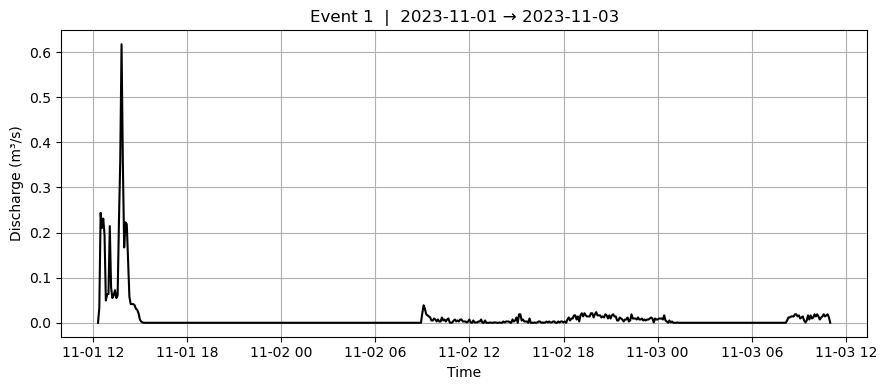

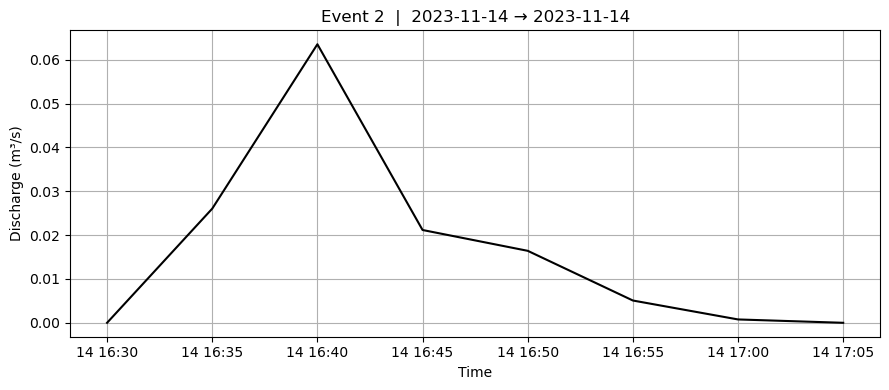

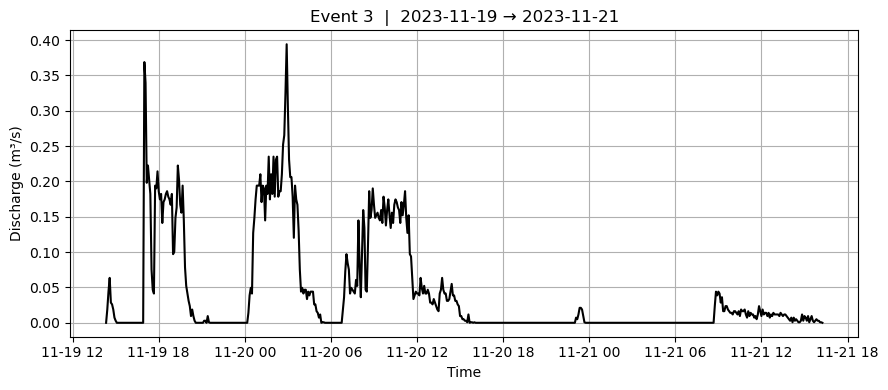

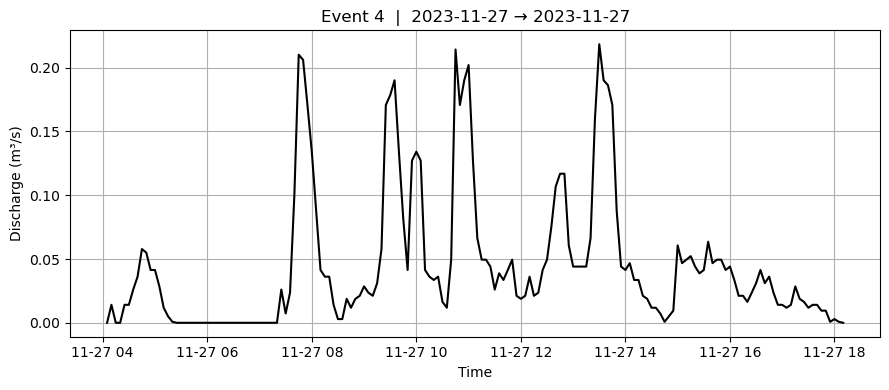

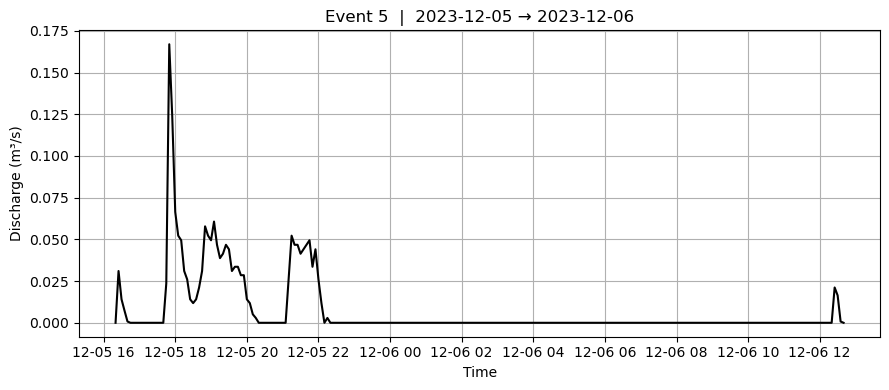

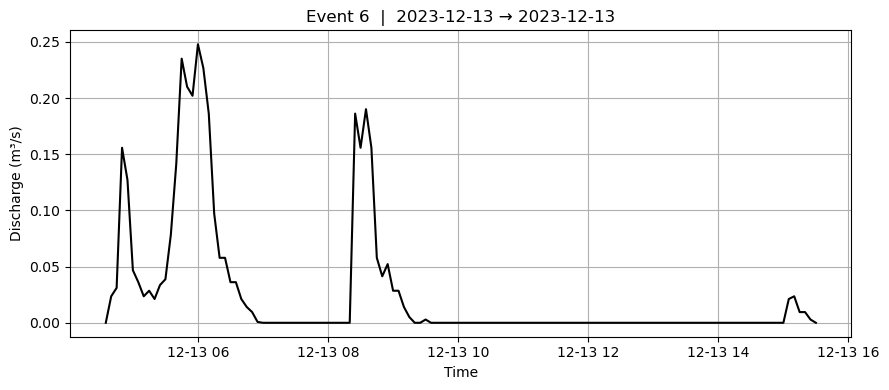

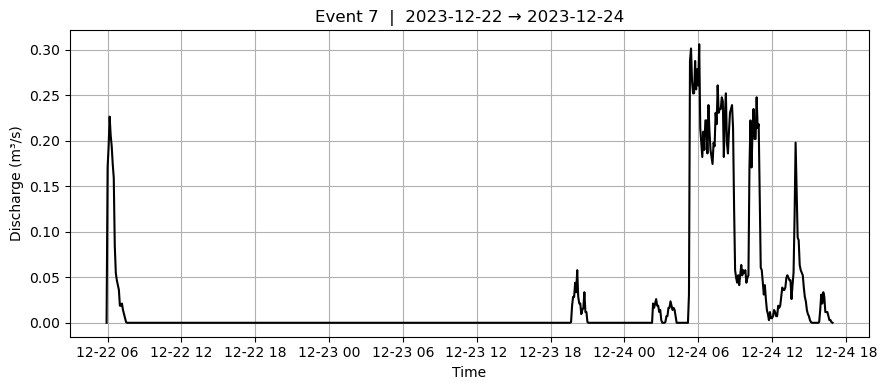

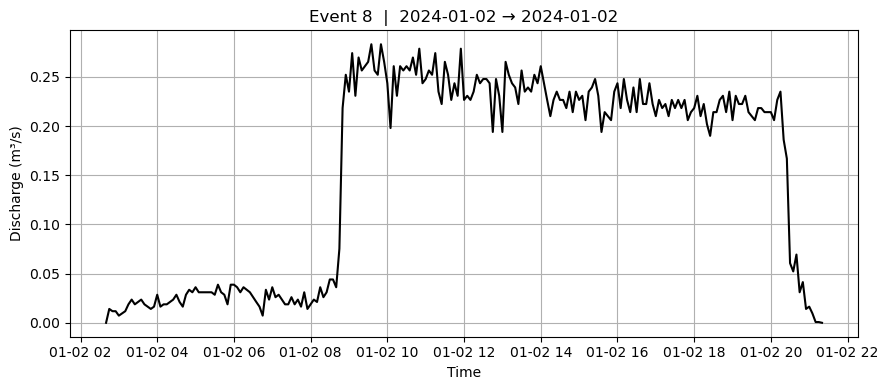

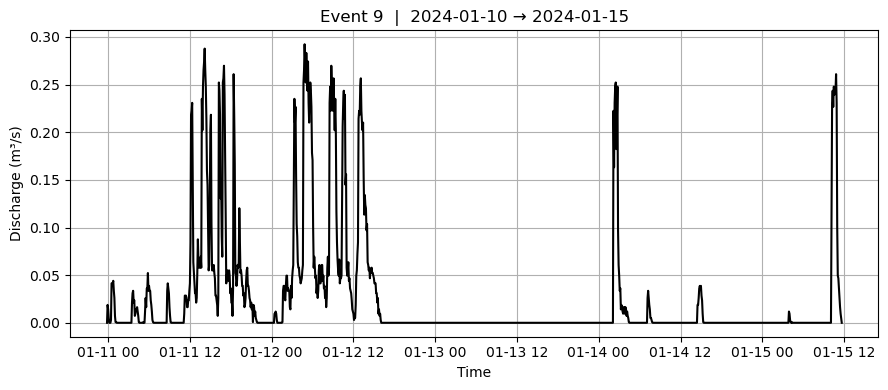

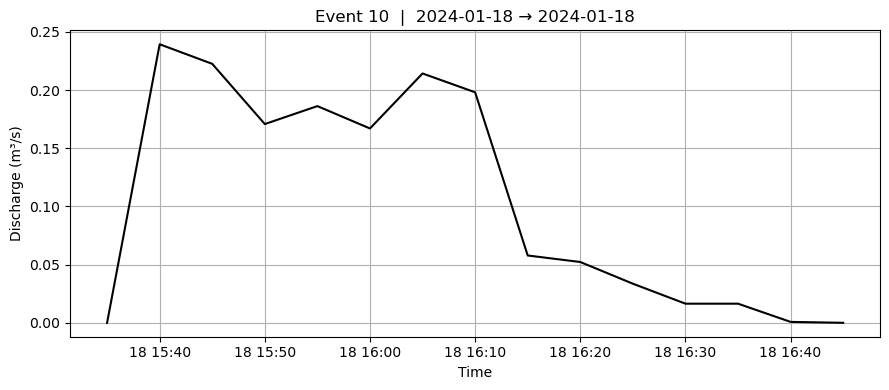

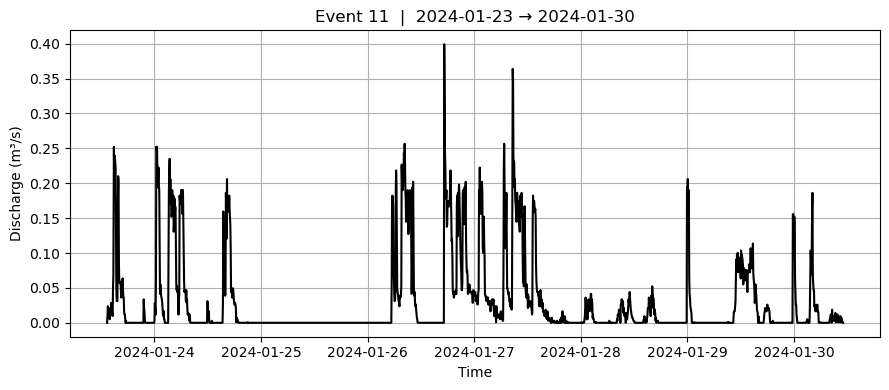

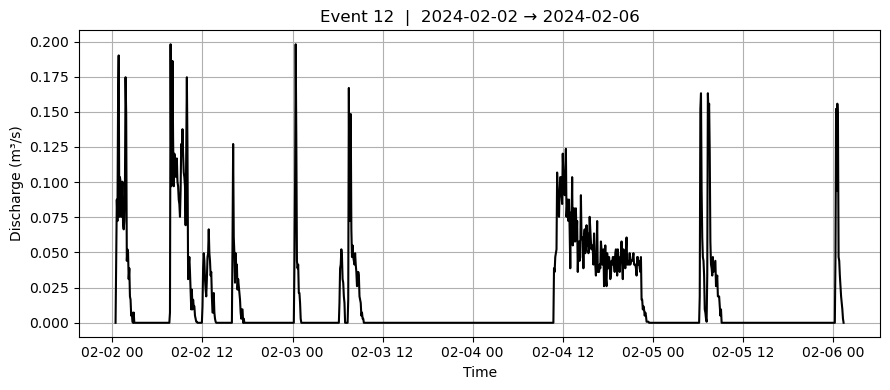

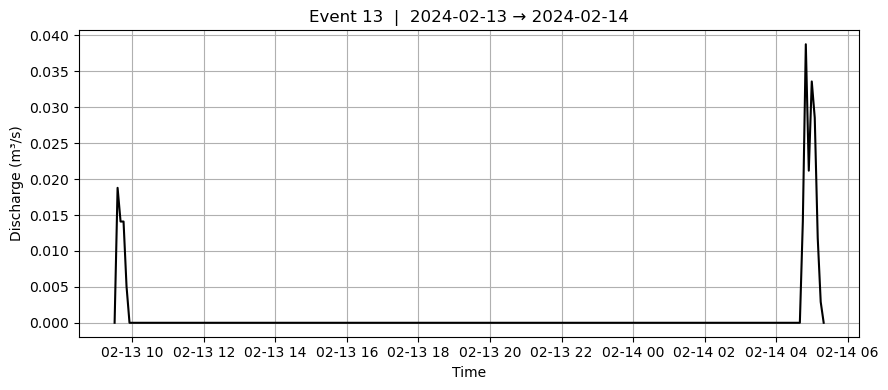

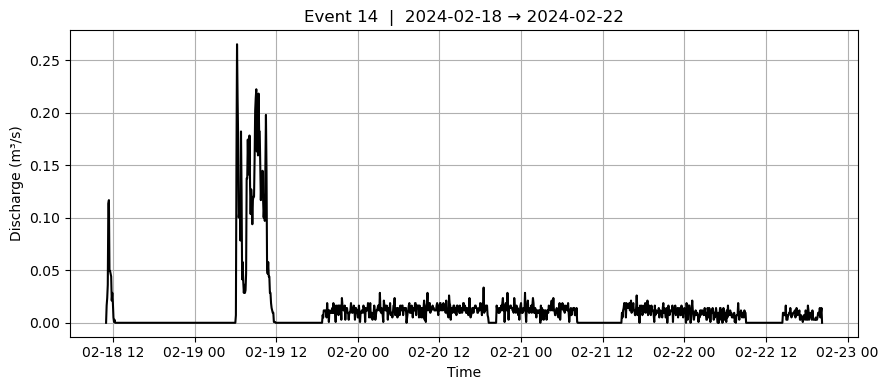

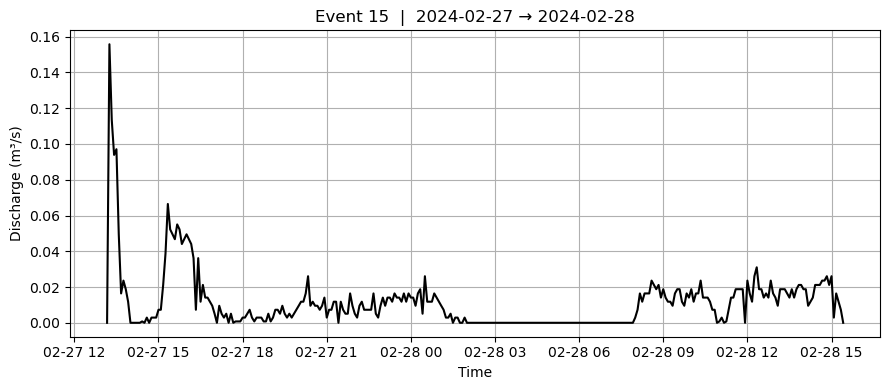

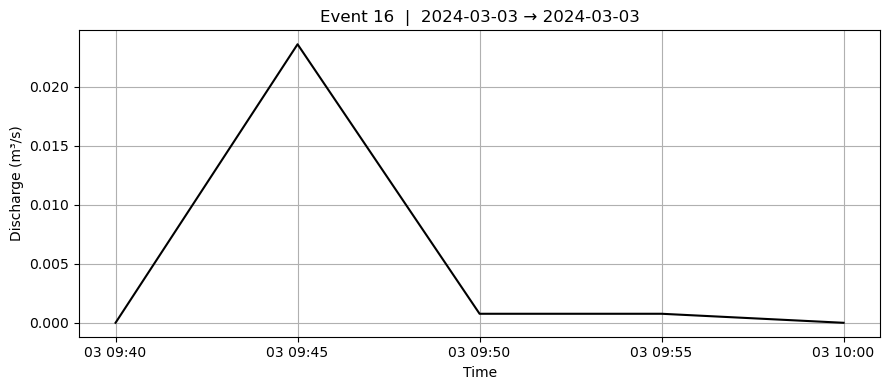

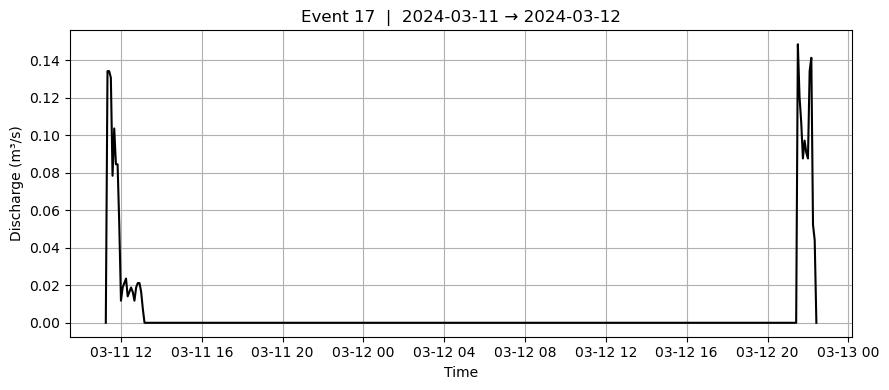

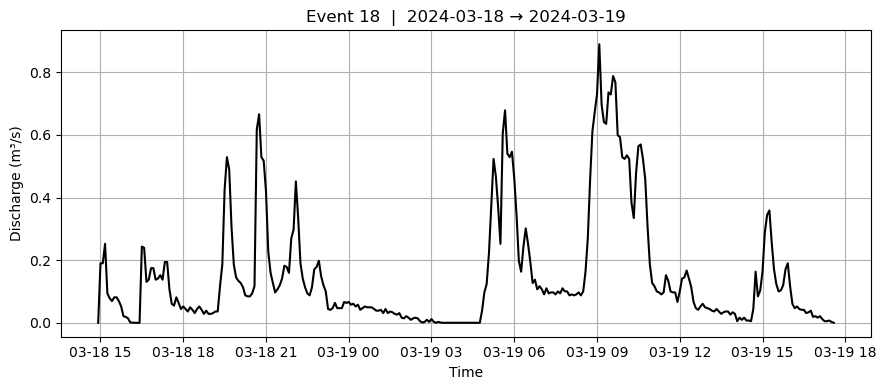

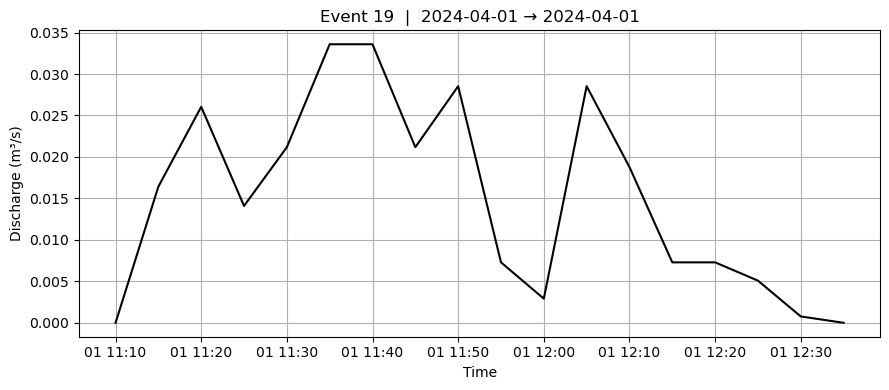

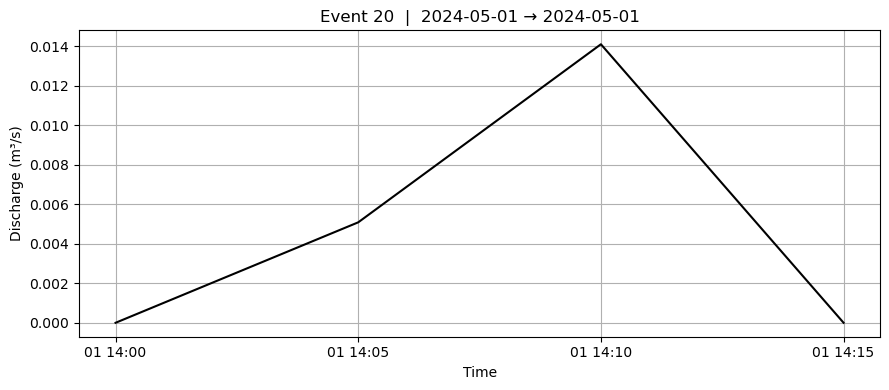

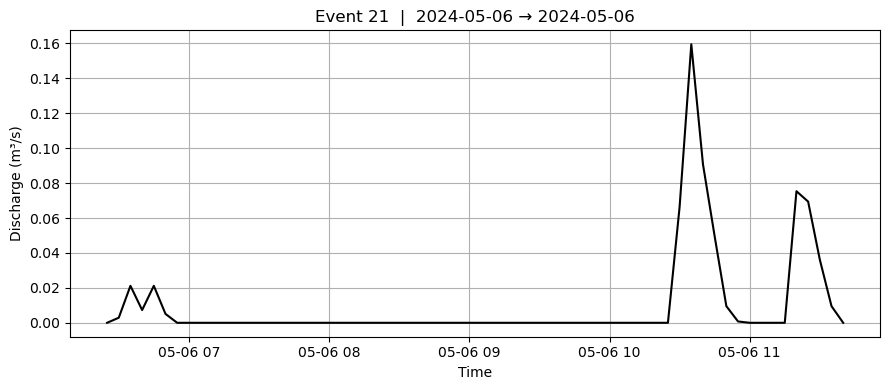

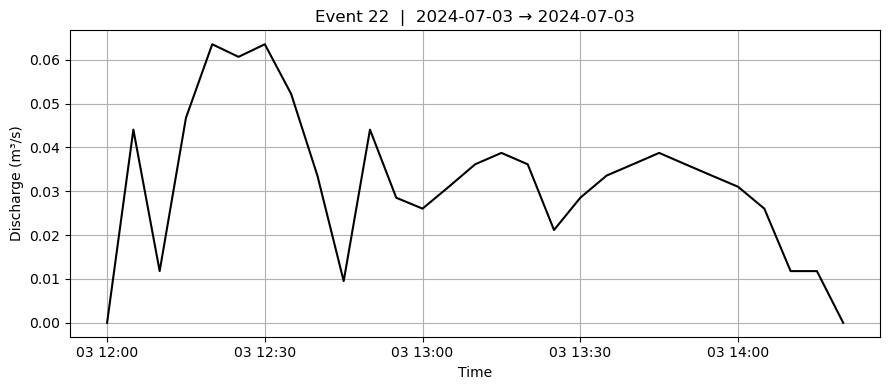

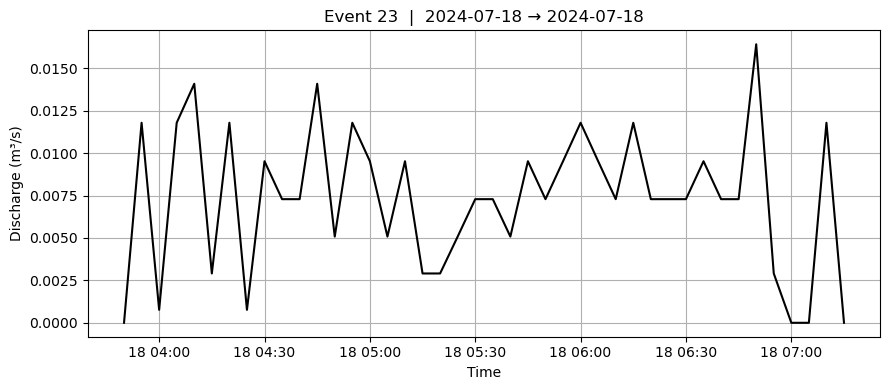

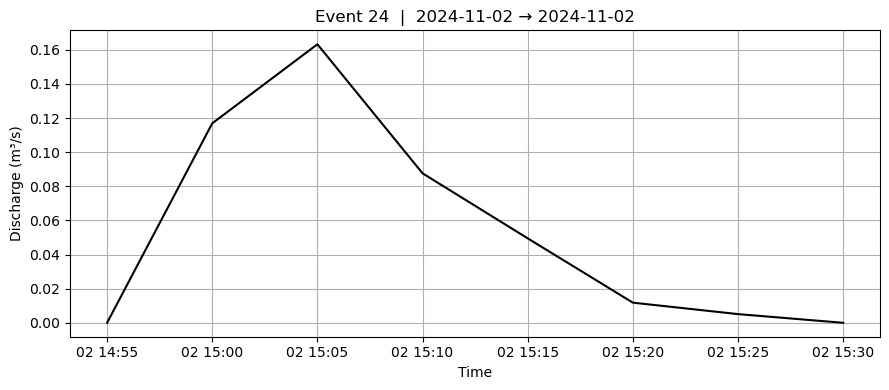

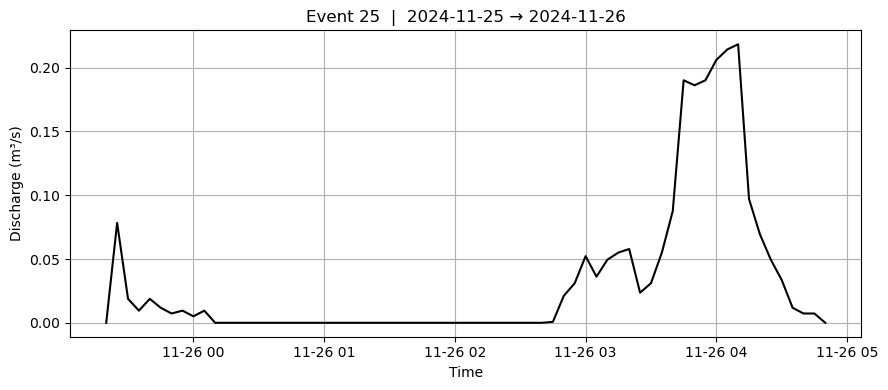

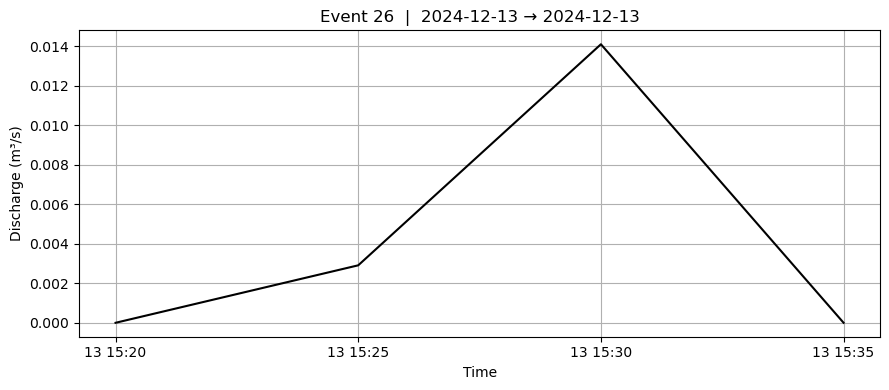

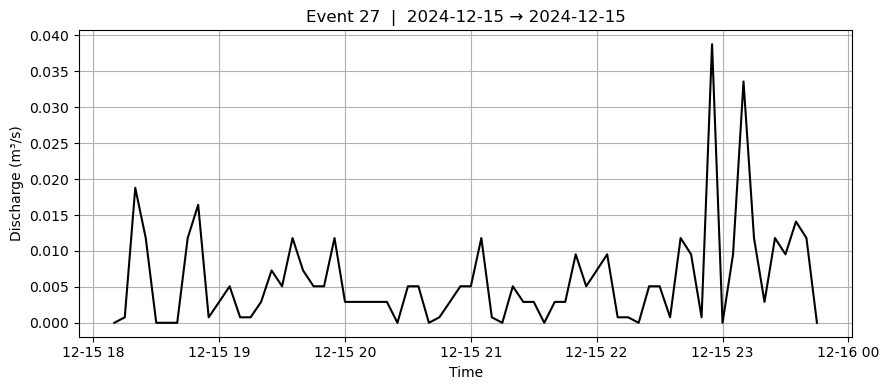

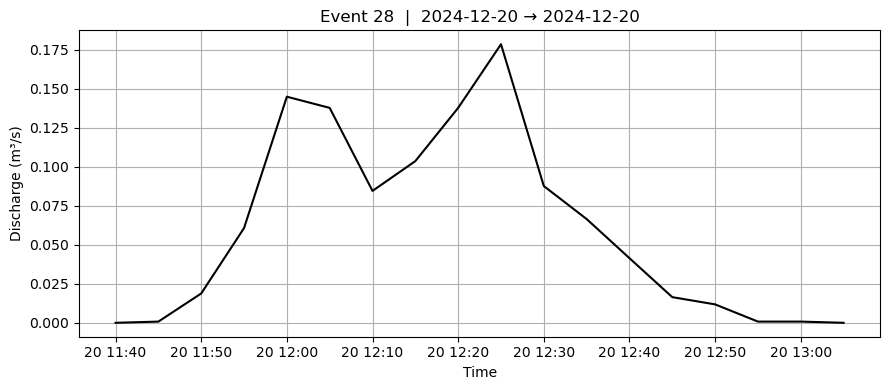

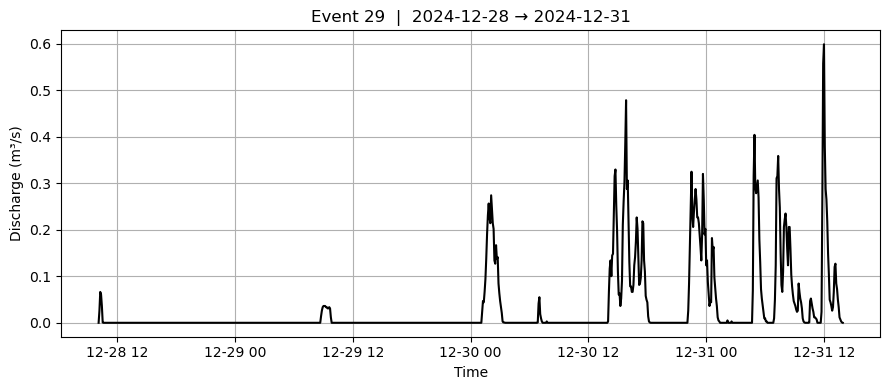

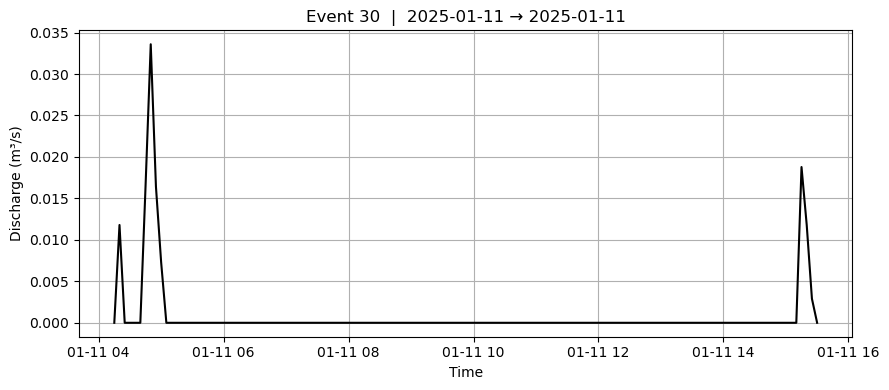

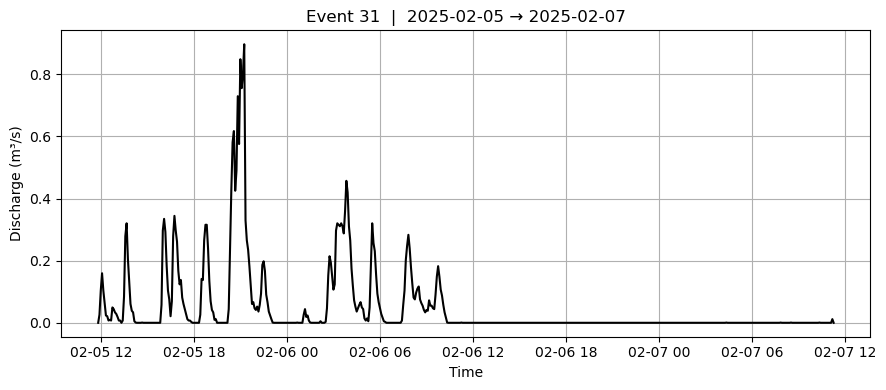

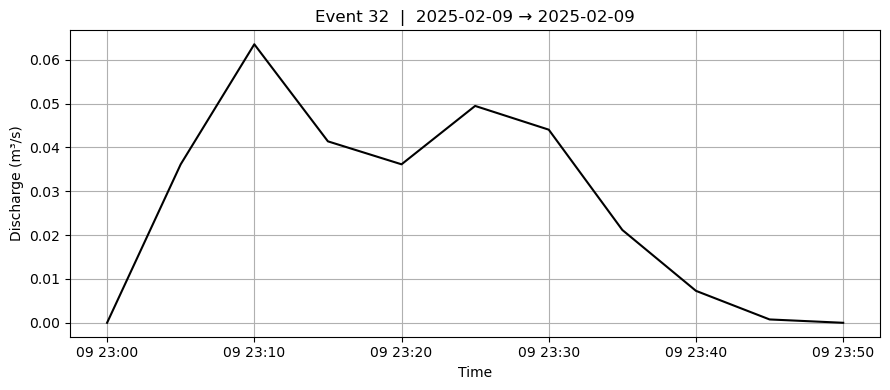

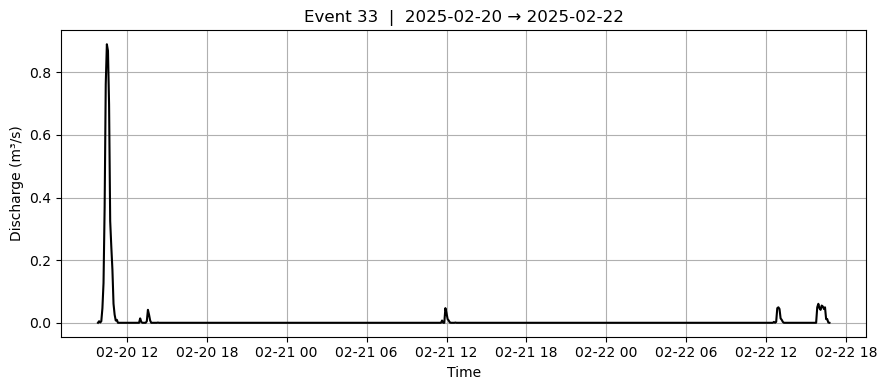

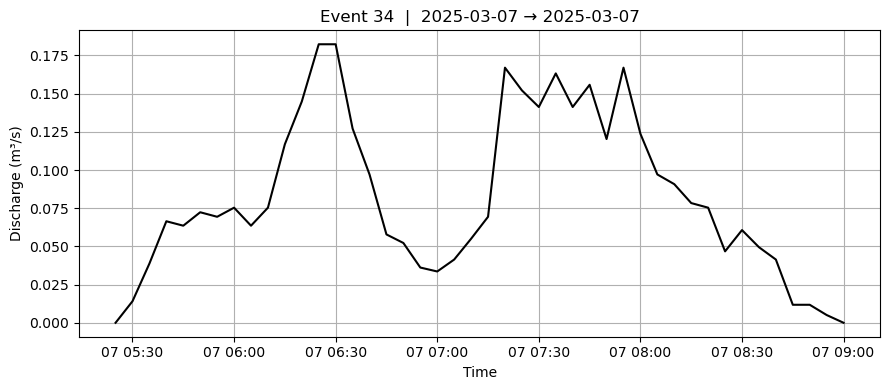

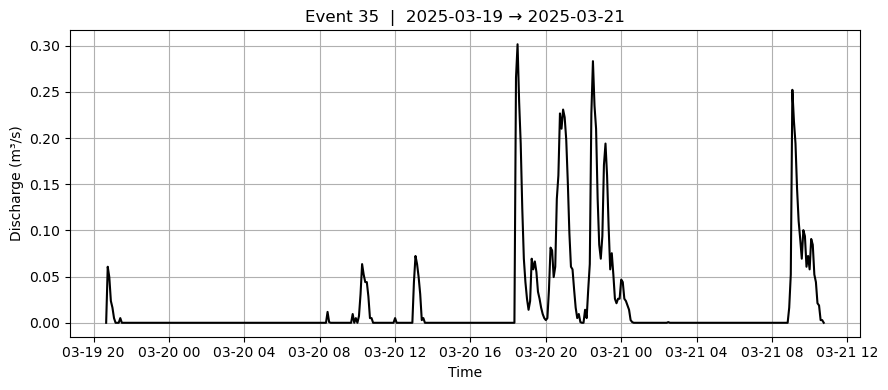

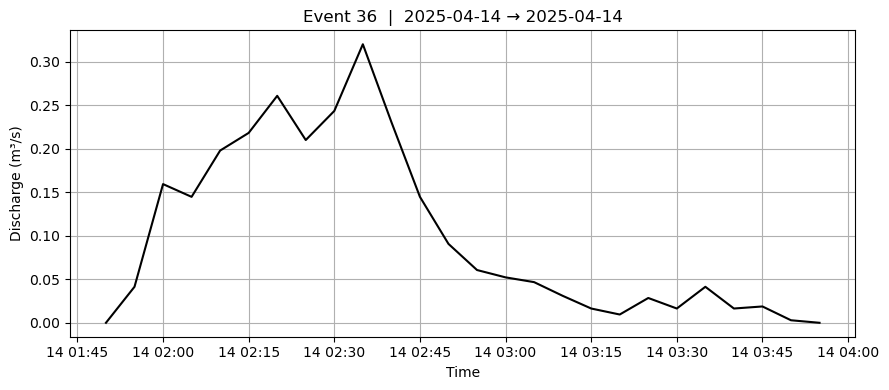

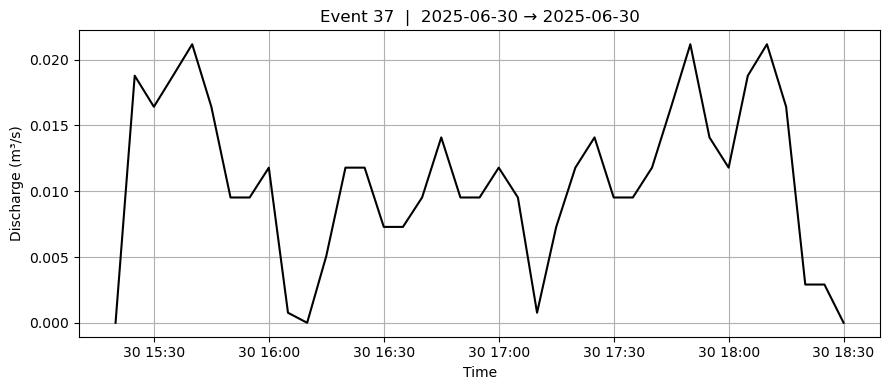

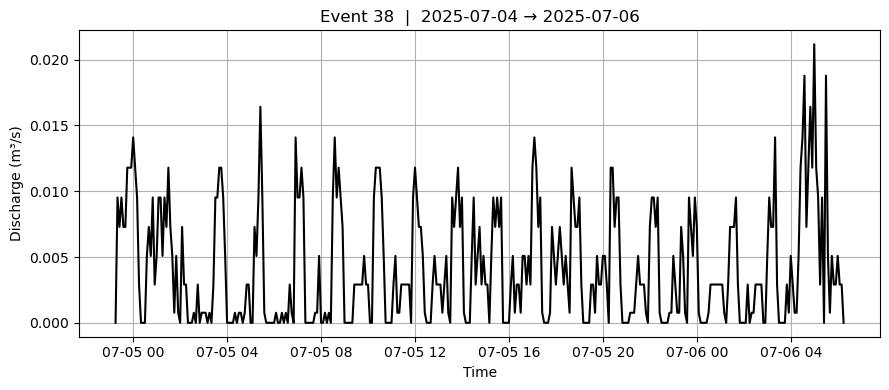

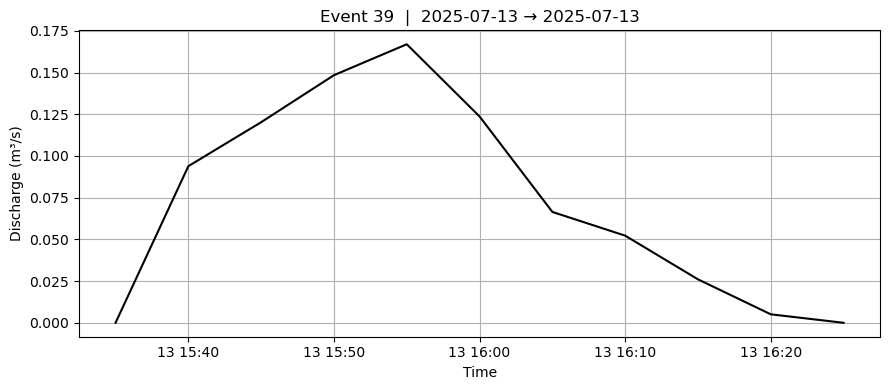

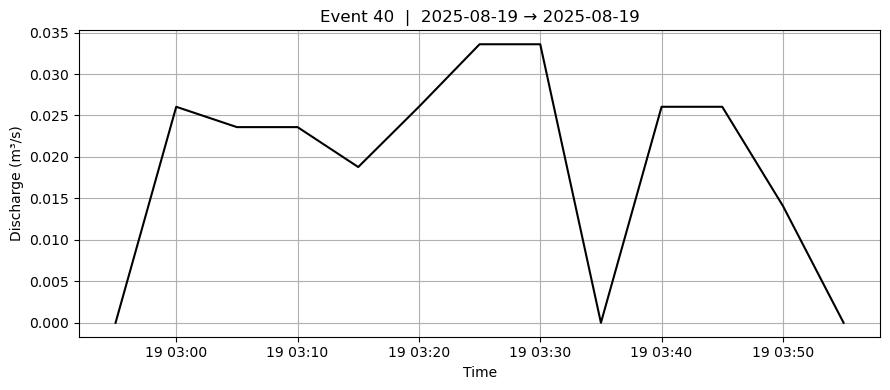

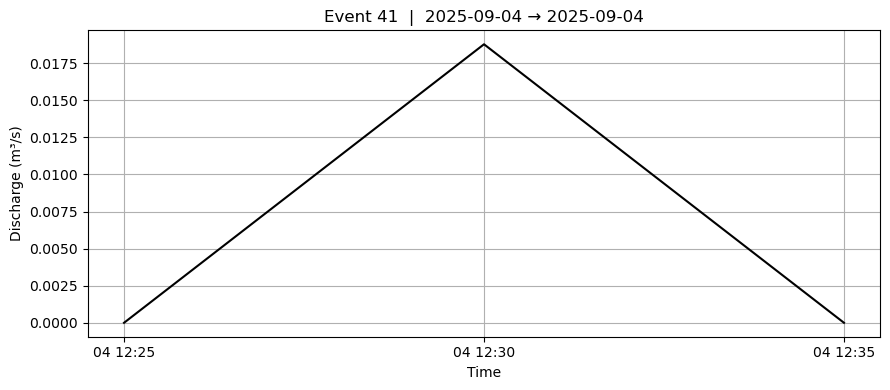

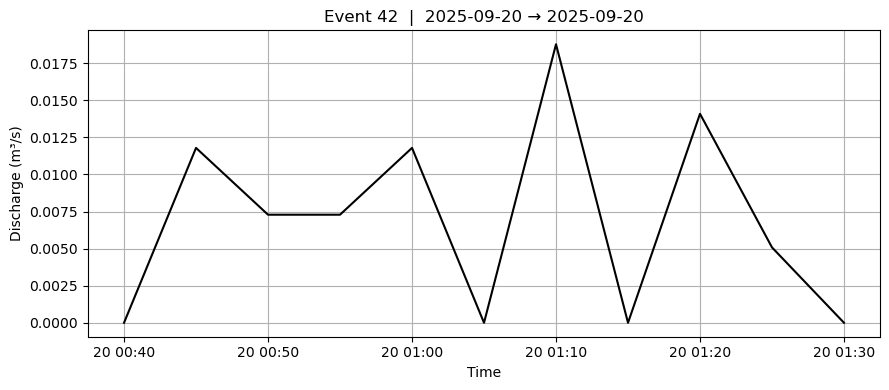

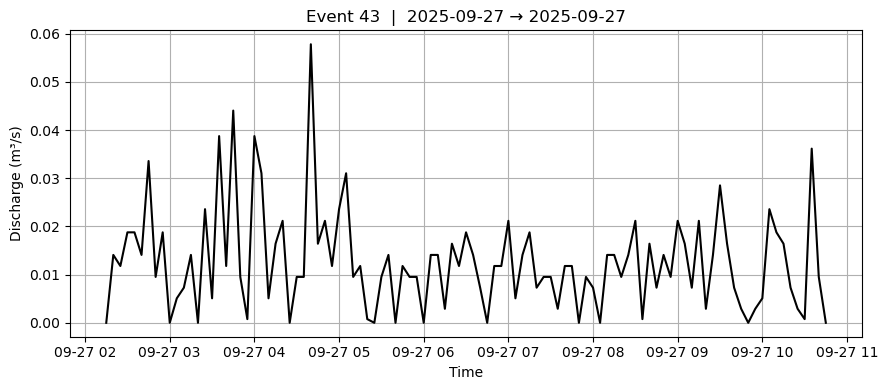

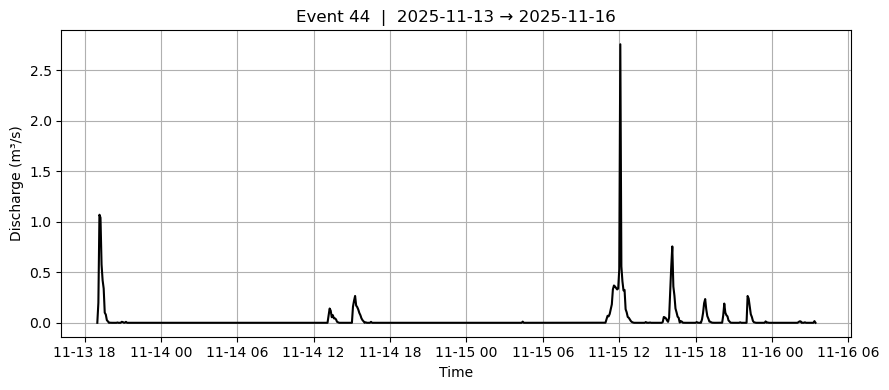

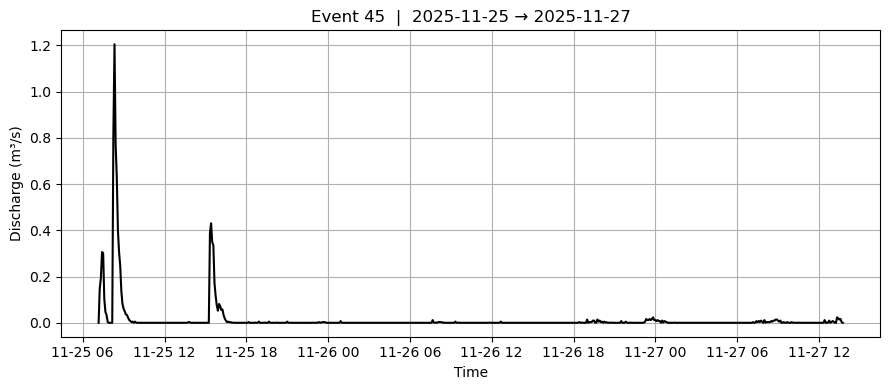

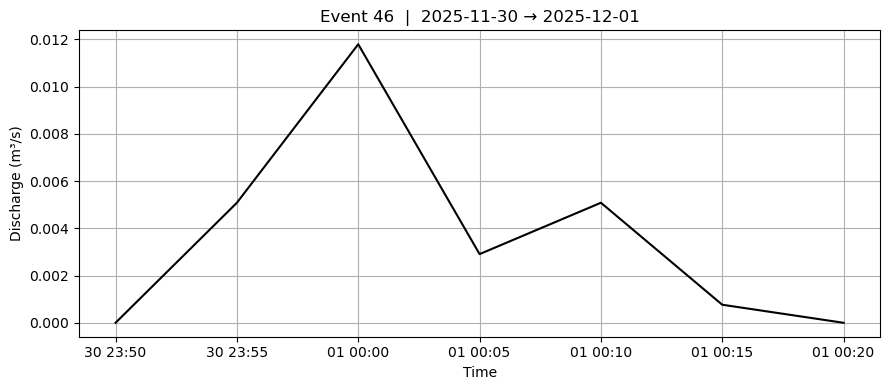

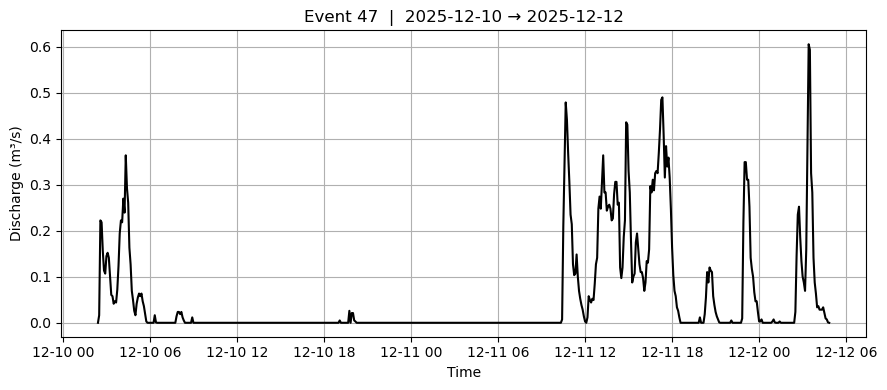

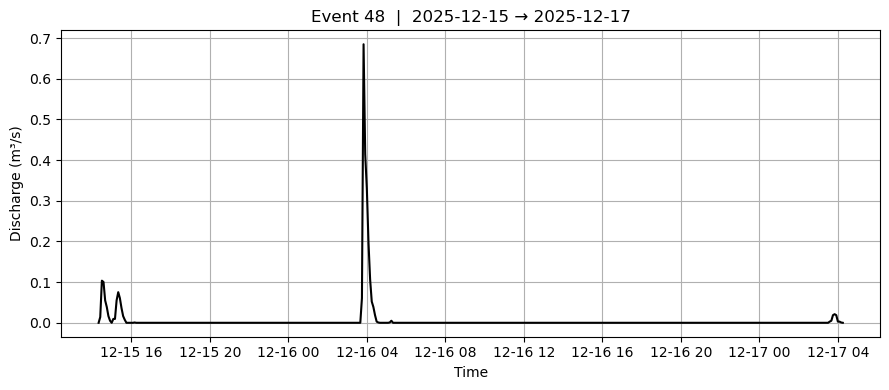

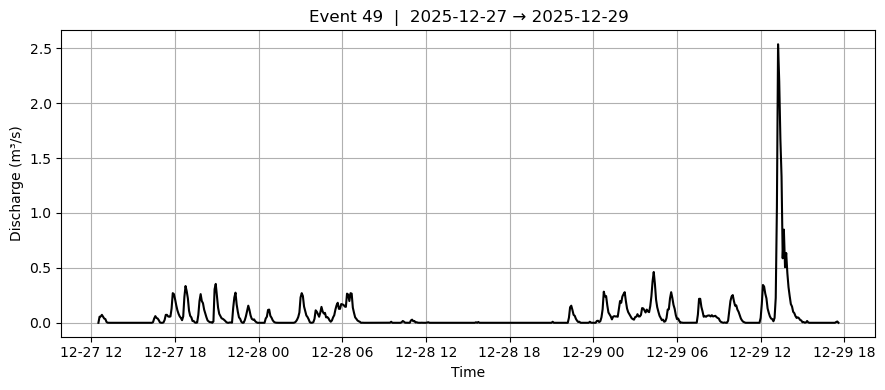

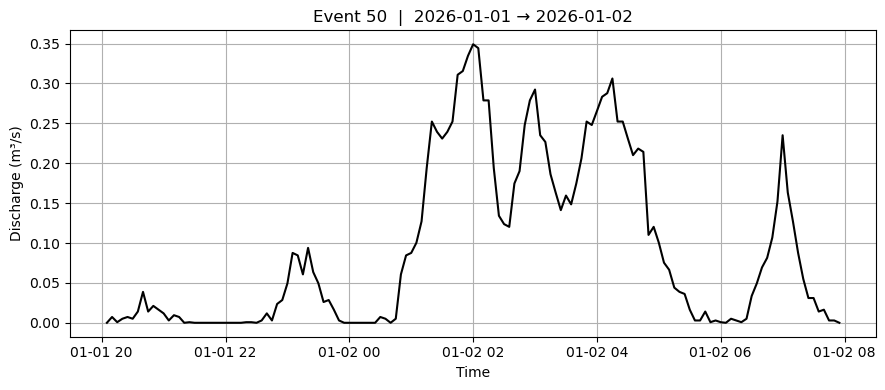

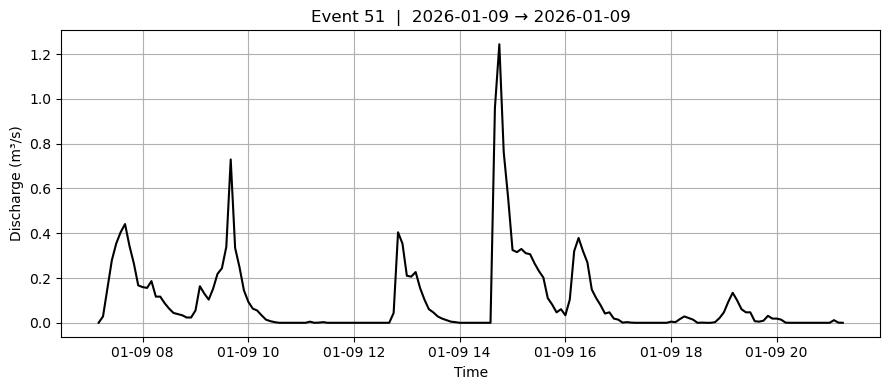

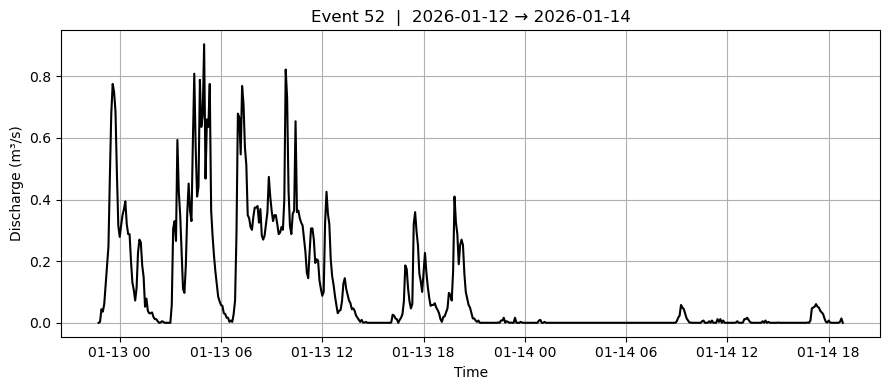

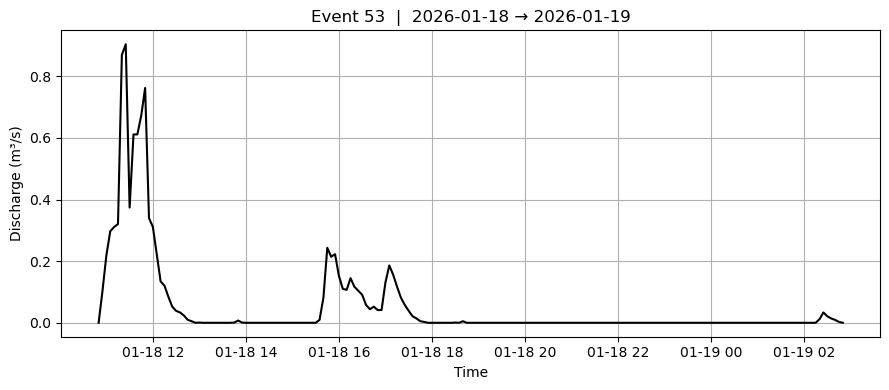

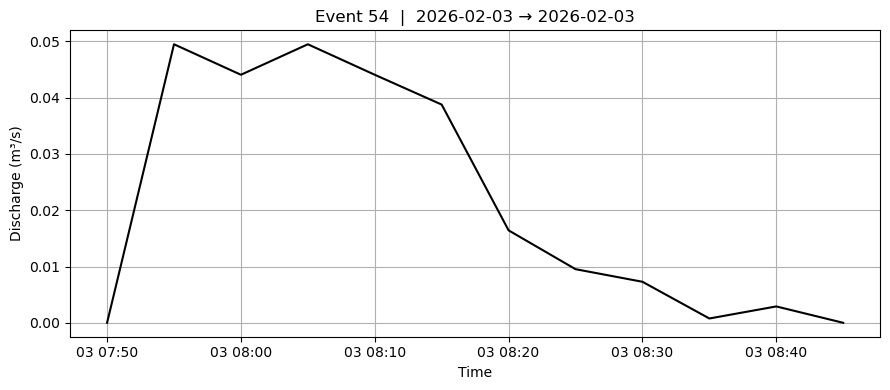

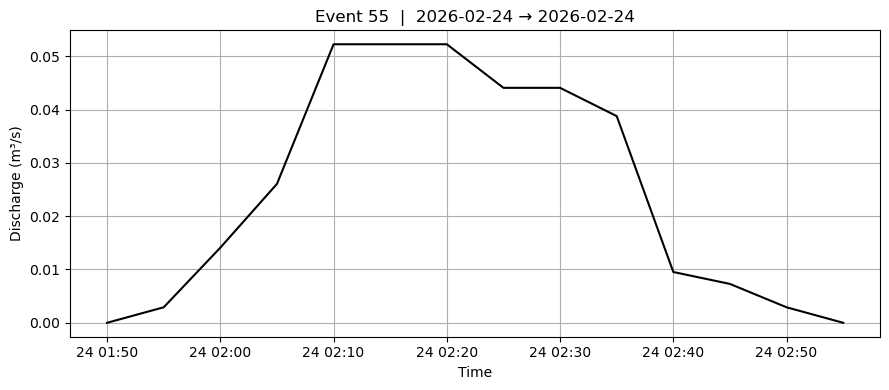

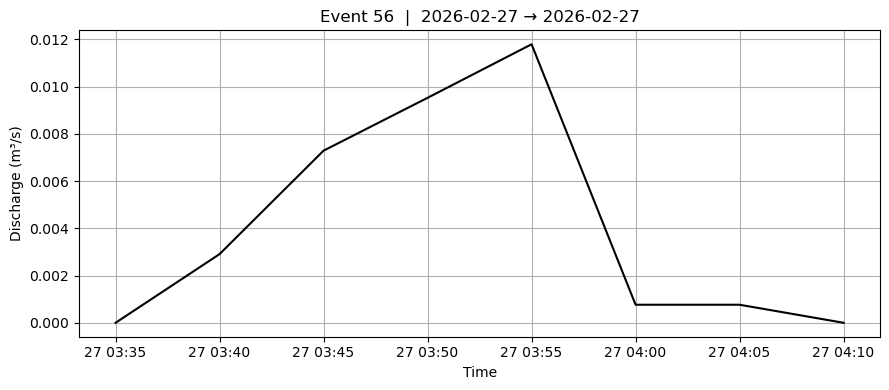

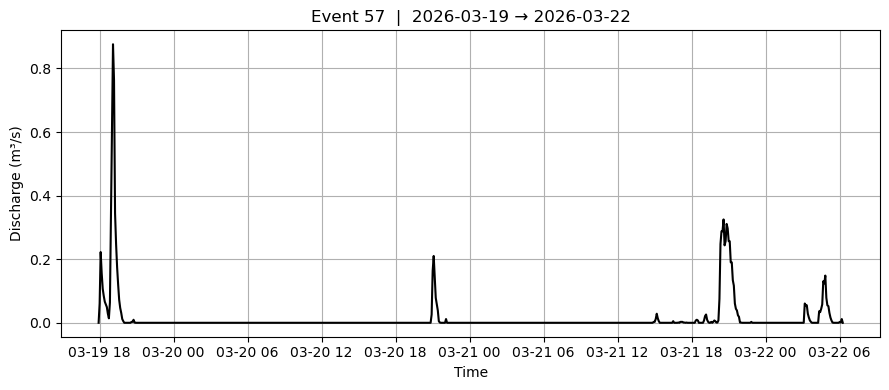

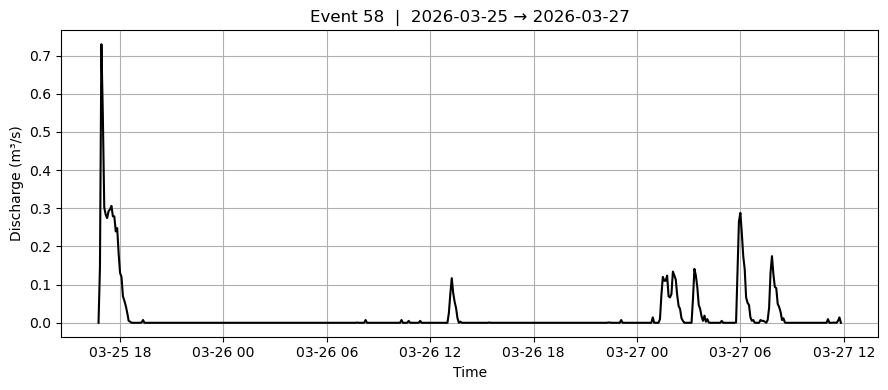

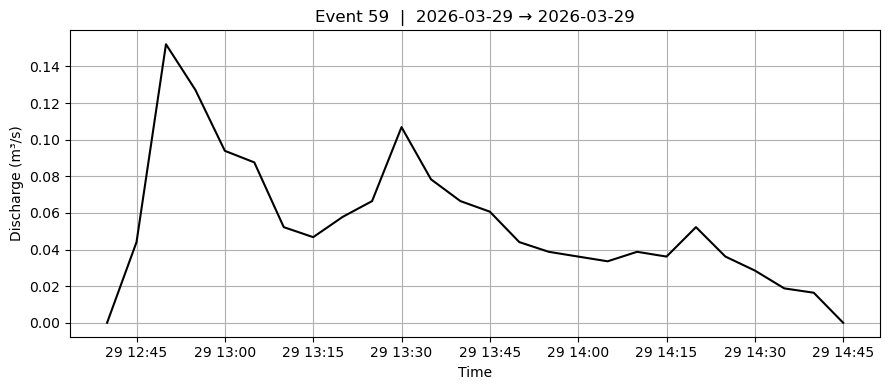

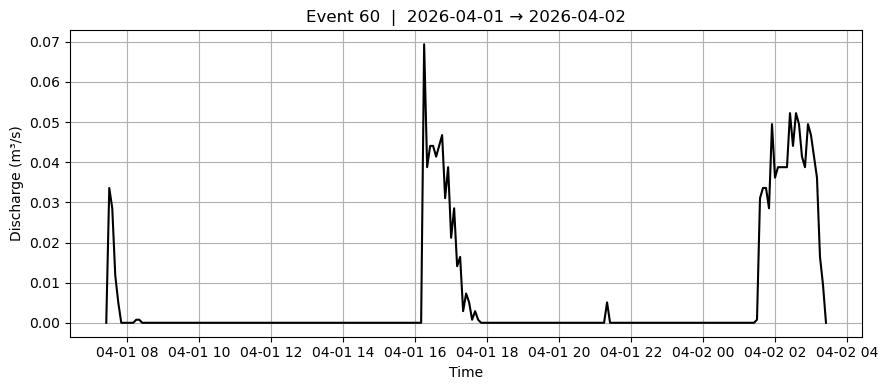

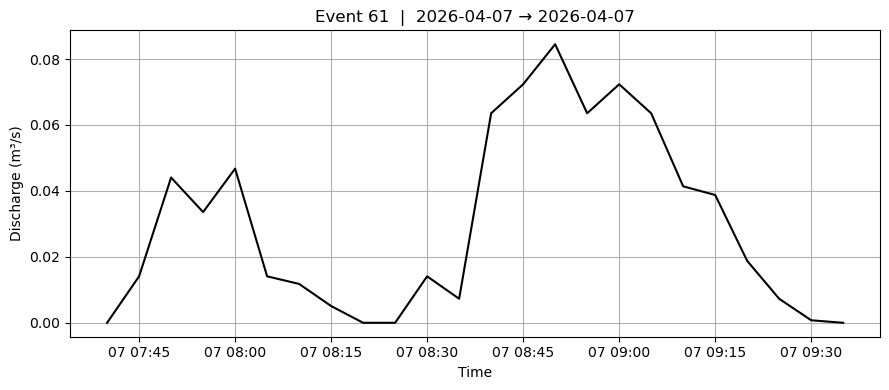

In [6]:
for i, event in flow_events.iterrows():
    seg = discharge[
        (discharge['timestamp'] >= event['flow_start']) &
        (discharge['timestamp'] <= event['flow_end'])
    ]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(seg['timestamp'], seg['discharge_cms'], color='black', linewidth=1.5)
    ax.set_title(f"Event {i+1}  |  {event['flow_start'].date()} → {event['flow_end'].date()}")
    ax.set_xlabel('Time')
    ax.set_ylabel('Discharge (m³/s)')
    ax.grid(True)
    fig.tight_layout()
    plt.show()

## 5  Statistical overview

C:\Users\raznu\AppData\Local\Temp\ipykernel_12160\823444710.py:1: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  nice_hist(flow_events['flow_peak_m3_s'],      bins=30,
C:\Users\raznu\AppData\Local\Temp\ipykernel_12160\823444710.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  nice_hist(flow_events['flow_total_volume_m3'], bins=30,


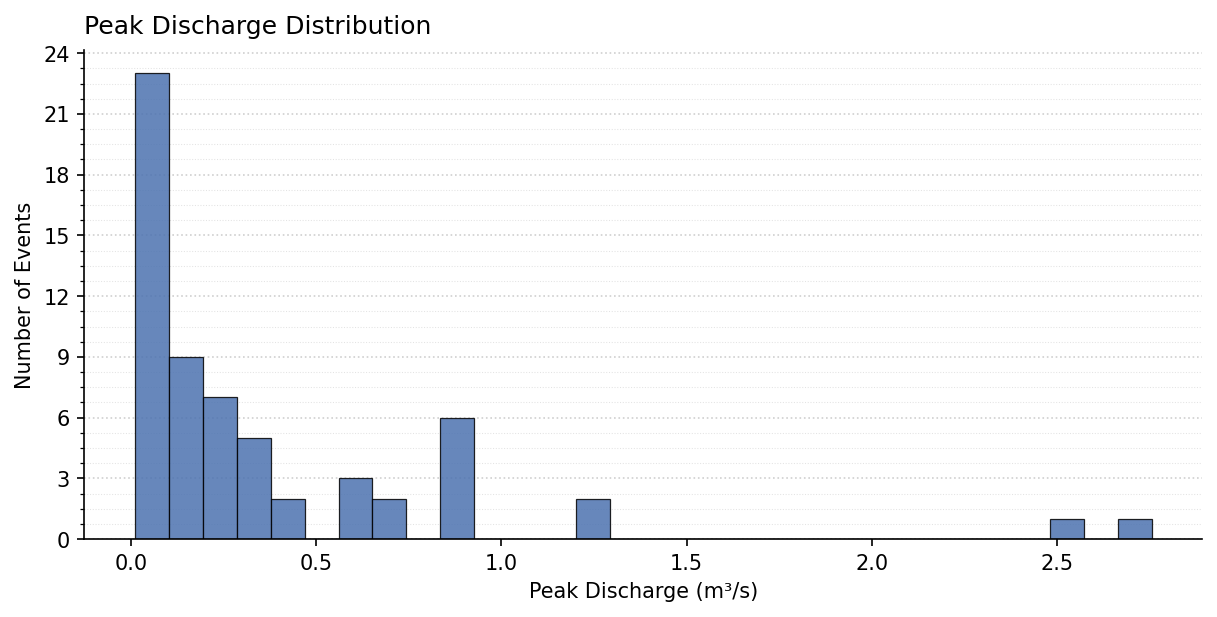

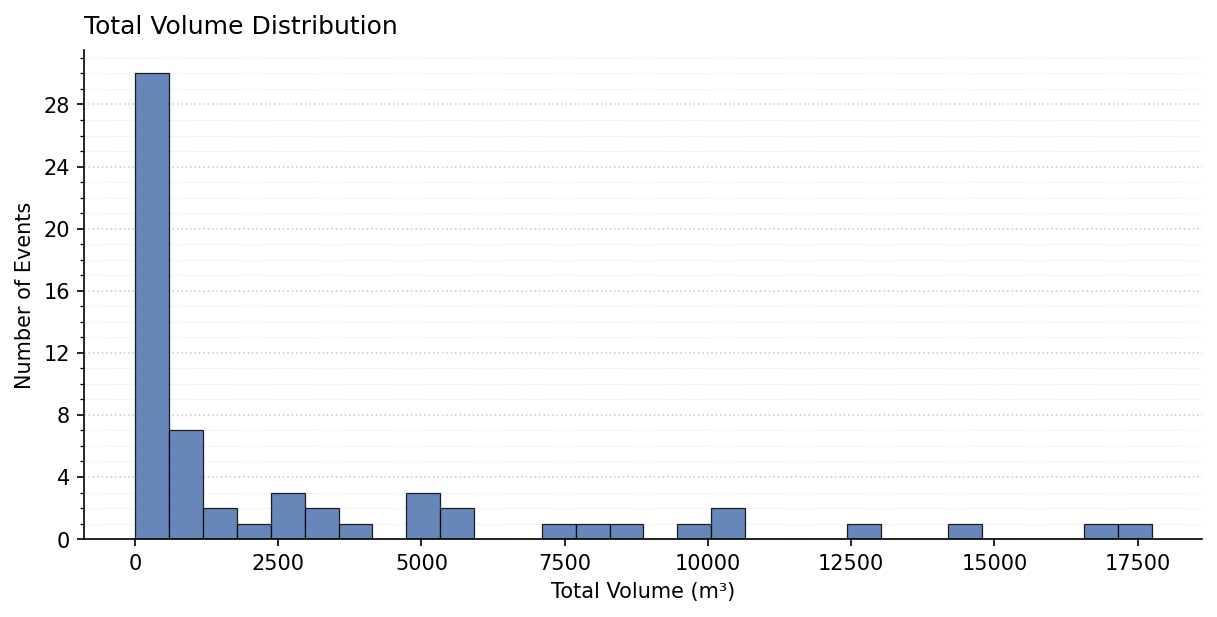

In [7]:
nice_hist(flow_events['flow_peak_m3_s'],      bins=30,
          title='Peak Discharge Distribution', xlabel='Peak Discharge (m³/s)').show()

nice_hist(flow_events['flow_total_volume_m3'], bins=30,
          title='Total Volume Distribution',   xlabel='Total Volume (m³)').show()

C:\Users\raznu\AppData\Local\Temp\ipykernel_12160\313338609.py:1: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  plot_events_over_time(flow_events).show()


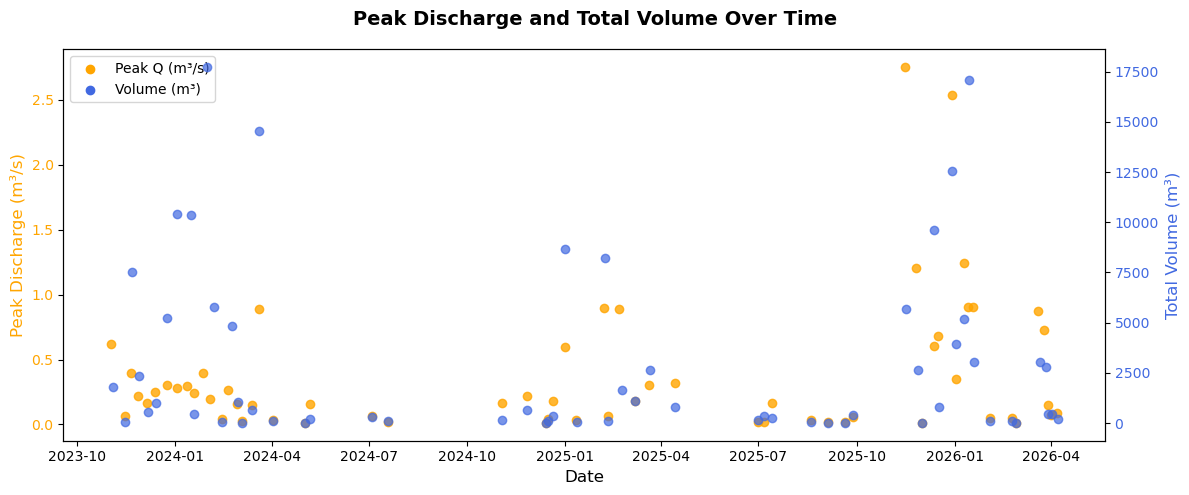

In [8]:
plot_events_over_time(flow_events).show()

C:\Users\raznu\AppData\Local\Temp\ipykernel_12160\538344047.py:5: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  nice_hist(flow_events['duration_hr'],     bins=30,
C:\Users\raznu\AppData\Local\Temp\ipykernel_12160\538344047.py:8: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  nice_hist(flow_events['time_to_peak_hr'], bins=30,


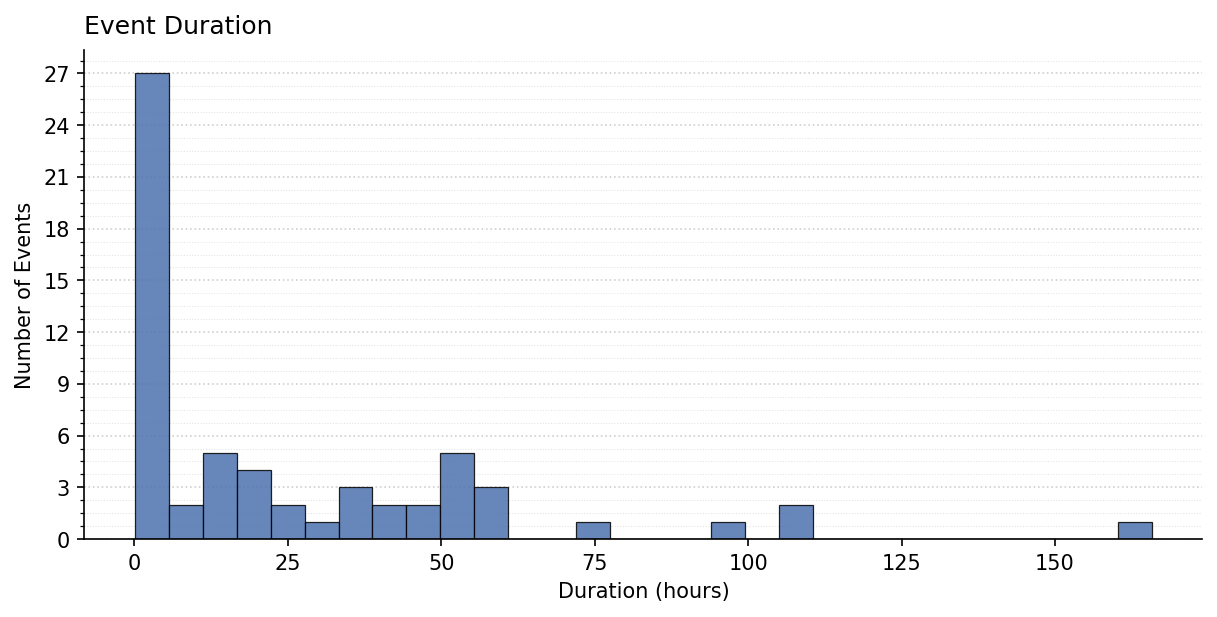

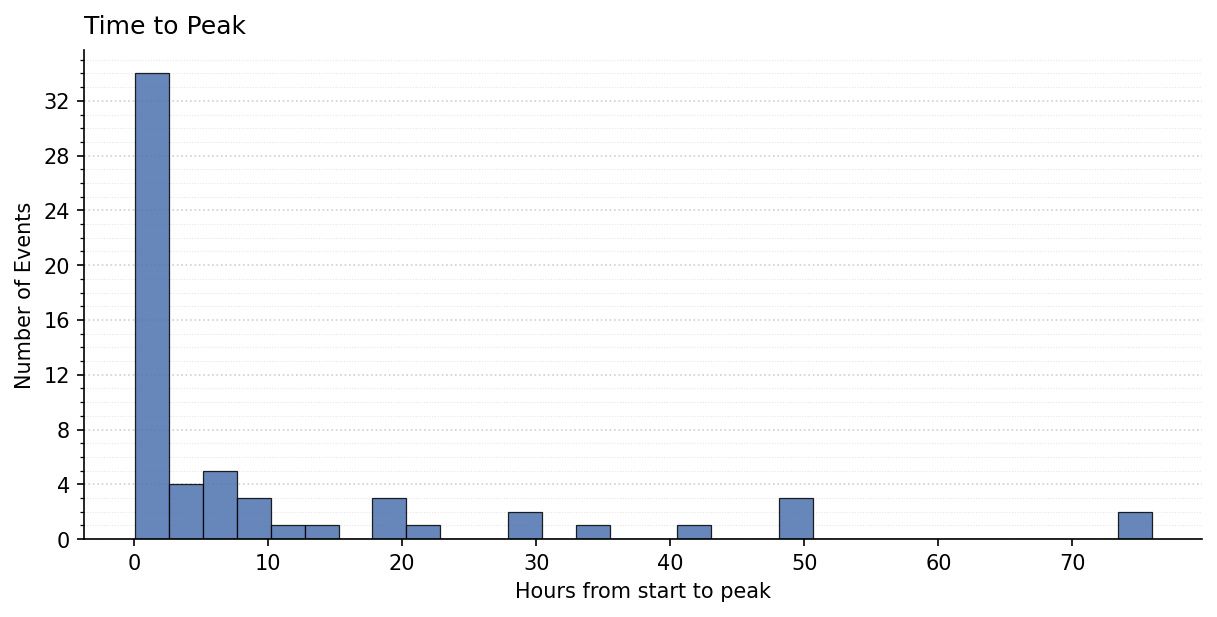

In [9]:
# Duration and time-to-peak
flow_events['duration_hr']       = (flow_events['flow_end'] - flow_events['flow_start']).dt.total_seconds() / 3600
flow_events['time_to_peak_hr']   = (flow_events['flow_peak_datetime'] - flow_events['flow_start']).dt.total_seconds() / 3600

nice_hist(flow_events['duration_hr'],     bins=30,
          title='Event Duration',         xlabel='Duration (hours)').show()

nice_hist(flow_events['time_to_peak_hr'], bins=30,
          title='Time to Peak',           xlabel='Hours from start to peak').show()

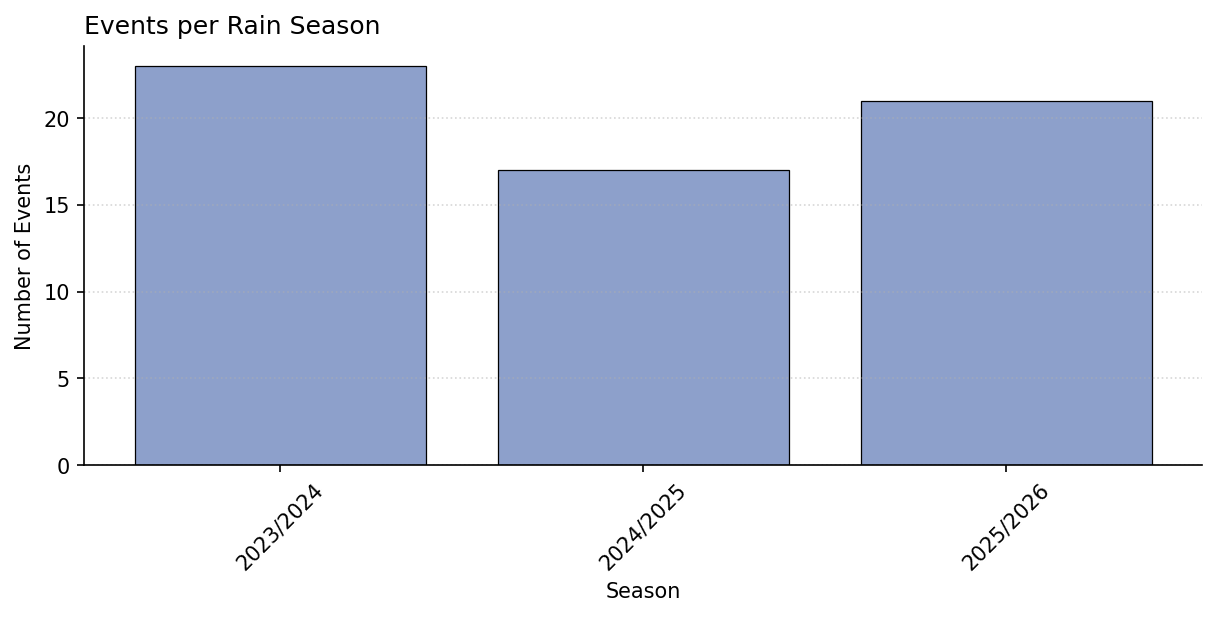

In [10]:
# Events per rain season (Sep–Aug)
flow_events['rain_season'] = flow_events['flow_start'].apply(
    lambda d: f"{d.year}/{d.year+1}" if d.month >= 9 else f"{d.year-1}/{d.year}"
)
season_counts = flow_events['rain_season'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4), dpi=150, constrained_layout=True)
ax.bar(season_counts.index, season_counts.values, color=cfg.STATIONS['gazelle_valley']['color'],
       edgecolor='black', linewidth=0.6)
ax.set_title('Events per Rain Season', loc='left')
ax.set_xlabel('Season')
ax.set_ylabel('Number of Events')
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.show()